# 04 — Baseline GBM: an untuned model and an honest performance assessment

**Kenya maize (One Acre Fund MEL Agronomic Survey, 2016–2020)**

This notebook establishes the **reference point** that every later modelling
decision has to beat. It trains gradient-boosted trees **at their stock library
defaults** — no hyperparameter search, no early stopping, no capacity tuning —
and then spends most of its length asking what the resulting model is and is not
good for.

### The one choice that was made

Feature selection is inherited, not redone: the 66 ex-ante, η²-pruned features
from `data/features/kenya_maize_recommended_features.csv` (notebook 03). Nothing
else is chosen. `LGBMRegressor()` is instantiated with no arguments beyond a
random seed.

### Evaluation protocol

Yield is predicted for the **2020 season, which no model here has ever seen**.
Training is 2016–2019. This is an out-of-time holdout: strictly harder than a
random split, and the actual deployment condition, since the model will always be
asked about a season that does not exist yet. Site-grouped CV and
leave-one-year-out are reported alongside to show how much the answer depends on
which protocol you pick.

### What this notebook concludes

| | |
|---|---|
| Stock LightGBM reaches **R² = +0.103** out-of-time | It beats a district-mean predictor (+0.007) decisively, so the features carry real information. |
| Stock XGBoost reaches **R² = −0.106** | "Use a GBM" is not a specification. Library defaults differ enough to flip the sign. |
| Grouped CV says +0.297, out-of-time says +0.103 | A ~2.9× gap. Quoting the CV number would overstate the model by a factor of three. |
| Predicted spread is **58% of actual spread** | Heavy regression to the mean: the bottom yield decile is over-predicted by ~1,500 kg/ha and the top under-predicted by ~2,800. |
| Only **33% of plots** land within ±20% of actual | As a plot-level forecast this is weak. |
| But it puts **48% of its bottom-quartile picks** in the true bottom quartile (chance = 25%) | As a *targeting* tool it is genuinely useful. That is the verdict. |

> **Prerequisite:** run `python scripts/build_features.py`, then notebook 03
> (which writes the recommended feature list this notebook loads).

## 0 · Setup

In [1]:
import os, warnings
from pathlib import Path

# joblib probes core count with `wmic`, absent on recent Windows; warm the cache
# quietly so it does not dump a traceback into every sklearn cell.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))
import contextlib, io as _io
with contextlib.redirect_stderr(_io.StringIO()):
    try:
        from joblib.externals.loky.backend import context as _lk
        _lk._count_physical_cores()
    except Exception:
        pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)

ROOT = Path.cwd()
while not (ROOT / "data" / "features").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
FEATURES = ROOT / "data" / "features"

TARGET, HOLDOUT_YEAR = "yield_kg_ph", 2020

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RED, VIOLET        = "#e34948", "#4a3aa7"
INK, INK2, MUTED   = "#0b0b0b", "#52514e", "#b4b3ad"
SURFACE            = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "axes.labelcolor": INK2,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": MUTED, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "legend.frameon": False, "figure.dpi": 110,
})

def style(ax, title=None, xlabel=None, ylabel=None, xgrid=False, ygrid=True):
    if title:  ax.set_title(title, loc="left", pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(axis="x" if xgrid else "y", visible=xgrid or ygrid)
    ax.set_axisbelow(True)
    return ax

print("lightgbm", lgb.__version__, "| xgboost", xgb.__version__)

lightgbm 4.7.0 | xgboost 3.3.0


In [2]:
def restore_dtypes(df):
    """Booleans round-trip through CSV as strings; pandas then guesses `bool` for
    columns with no missing values and `object` for those with. Cast the whole
    block to float so every downstream operation sees one representation."""
    for c in df.columns:
        if df[c].dtype == bool:
            df[c] = df[c].astype(float)
        elif df[c].dtype == object:
            vals = set(df[c].dropna().unique())
            if vals and vals <= {True, False, "True", "False"}:
                df[c] = df[c].map({True: 1.0, False: 0.0,
                                   "True": 1.0, "False": 0.0}).astype(float)
    return df

full = restore_dtypes(pd.read_csv(FEATURES / "kenya_maize_features_full.csv",
                                  low_memory=False))
rec  = pd.read_csv(FEATURES / "kenya_maize_recommended_features.csv")

FEATS = rec.feature.tolist()
CATS  = [c for c in FEATS if full[c].dtype == object]
for c in CATS:
    full[c] = full[c].astype("category")

is_train = full.year < HOLDOUT_YEAR
is_hold  = full.year == HOLDOUT_YEAR
X, y     = full[FEATS], full[TARGET]
y_hold   = y[is_hold].to_numpy()

print(f"features: {len(FEATS)} (from notebook 03's recommended set)")
print(f"  roles: {rec.role.value_counts().to_dict()}")
print(f"  categorical: {CATS}")
print(f"\ntrain 2016-2019: {is_train.sum():,} rows"
      f"   holdout {HOLDOUT_YEAR}: {is_hold.sum():,} rows")
print(f"holdout yield: mean {y_hold.mean():,.0f}  sd {y_hold.std():,.0f}  "
      f"median {np.median(y_hold):,.0f} kg/ha")

features: 66 (from notebook 03's recommended set)
  roles: {'lever': 33, 'condition': 22, 'flag': 11}
  categorical: ['district', 'seed_type', 'seed_type_clean', 'seed_category', 'seed_type_primary', 'intercrop_type']

train 2016-2019: 17,484 rows   holdout 2020: 6,190 rows
holdout yield: mean 3,120  sd 1,591  median 2,965 kg/ha


In [3]:
def scores(pred, actual=None):
    a = y_hold if actual is None else actual
    return dict(
        r2   = r2_score(a, pred),
        mae  = mean_absolute_error(a, pred),
        rmse = float(np.sqrt(mean_squared_error(a, pred))),
        bias = float(np.mean(pred - a)),
        rho  = float(stats.spearmanr(a, pred).statistic)
              if np.std(pred) > 0 else np.nan,
    )

def show(pred, label, store=None):
    s = scores(pred); s["model"] = label
    print(f"  {label:34s} R²={s['r2']:+.4f}  MAE={s['mae']:7.0f}  "
          f"RMSE={s['rmse']:7.0f}  bias={s['bias']:+7.0f}  ρ={s['rho']:+.3f}"
          if not np.isnan(s["rho"]) else
          f"  {label:34s} R²={s['r2']:+.4f}  MAE={s['mae']:7.0f}  "
          f"RMSE={s['rmse']:7.0f}  bias={s['bias']:+7.0f}  ρ=    n/a")
    if store is not None:
        store.append(s)
    return s

## 1 · Reference points — what does the model have to beat?

An R² near zero sounds like failure and an R² of 0.10 sounds like success, but
neither statement means anything without a floor. Two floors matter here:

- **The global mean.** Predict the training-year average for every plot. This is
  what R² = 0 is defined against.
- **The district mean.** Predict each district's training average. This is the
  real competitor, because notebook 03 established that `district` carries ~60%
  of the model's holdout skill — so a lookup table is a serious baseline, and any
  model that fails to beat it has learned nothing but geography.

In [4]:
board = []
print("NAIVE BASELINES — 2020 holdout")
show(np.full(len(y_hold), y[is_train].mean()),   "global mean (train)",   board)
show(np.full(len(y_hold), y[is_train].median()), "global median (train)", board)

dist_mean = full.loc[is_train].groupby("district", observed=True)[TARGET].mean()
show(full.loc[is_hold, "district"].map(dist_mean)
         .fillna(y[is_train].mean()).to_numpy(),  "district mean (train)", board)

# A "recency" variant: only the two most recent training years, in case district
# productivity drifts. It does not help, which is itself worth knowing.
dm_recent = (full.loc[is_train & (full.year >= 2018)]
                 .groupby("district", observed=True)[TARGET].mean())
show(full.loc[is_hold, "district"].map(dm_recent)
         .fillna(y[is_train].mean()).to_numpy(), "district mean (2018-19 only)", board)

NAIVE BASELINES — 2020 holdout
  global mean (train)                R²=-0.0006  MAE=   1240  RMSE=   1591  bias=    +40  ρ=    n/a
  global median (train)              R²=-0.0159  MAE=   1230  RMSE=   1603  bias=   -201  ρ=    n/a
  district mean (train)              R²=+0.0068  MAE=   1238  RMSE=   1585  bias=    +45  ρ=+0.233
  district mean (2018-19 only)       R²=-0.0083  MAE=   1244  RMSE=   1597  bias=     -3  ρ=+0.228


{'r2': -0.008287026078518611,
 'mae': 1243.7248613726817,
 'rmse': 1597.3346337726946,
 'bias': -3.4378410853871544,
 'rho': 0.22756783225649327,
 'model': 'district mean (2018-19 only)'}

The district lookup scores **R² = +0.007** — barely above the global mean.

This is the first substantive result and it cuts against the obvious reading of
notebook 03. `district` being the model's most important feature does **not** mean
district averages predict yield well; it means district is the most useful thing
*available* in a set where nothing predicts individual plots well. Between-district
differences are real but small next to the plot-to-plot spread inside a district.

Restricting to recent years makes it slightly worse, so district productivity is
not drifting in a way a shorter window captures.

## 2 · Stock GBMs, no tuning

Three standard implementations, each instantiated with **library defaults** and a
seed. No search, no early stopping, no class of parameter touched. LightGBM and
`HistGradientBoostingRegressor` are told which columns are categorical, because
that is a *data-typing* statement rather than a tuning choice; XGBoost gets
integer codes, which is the ordinary thing to do without extra configuration.

In [5]:
print("STOCK GBMs — 2020 holdout, no tuning")

m_lgb = lgb.LGBMRegressor(random_state=0, verbose=-1)
m_lgb.fit(X.loc[is_train], y[is_train])
pred_lgb = m_lgb.predict(X.loc[is_hold])
show(pred_lgb, "LightGBM (defaults)", board)

# XGBoost cannot take pandas categoricals without enable_categorical; integer
# codes are the default-path equivalent. Note this imposes a false ordering on
# district, which matters for the result below.
X_codes = X.copy()
for c in CATS:
    X_codes[c] = X_codes[c].cat.codes.replace(-1, np.nan)

m_xgb = xgb.XGBRegressor(random_state=0, tree_method="hist")
m_xgb.fit(X_codes.loc[is_train], y[is_train])
show(m_xgb.predict(X_codes.loc[is_hold]), "XGBoost (defaults)", board)

m_skl = HistGradientBoostingRegressor(
    random_state=0, categorical_features=[X_codes.columns.get_loc(c) for c in CATS])
m_skl.fit(X_codes.loc[is_train], y[is_train])
show(m_skl.predict(X_codes.loc[is_hold]), "sklearn HistGBR (defaults)", board)

print("\nLightGBM's stock settings:")
print("  ", {k: m_lgb.get_params()[k] for k in
      ["n_estimators", "num_leaves", "learning_rate", "max_depth",
       "min_child_samples", "subsample", "colsample_bytree", "reg_lambda"]})

STOCK GBMs — 2020 holdout, no tuning


  LightGBM (defaults)                R²=+0.1031  MAE=   1151  RMSE=   1507  bias=    -89  ρ=+0.401


  XGBoost (defaults)                 R²=-0.1056  MAE=   1281  RMSE=   1673  bias=    -55  ρ=+0.291


  sklearn HistGBR (defaults)         R²=+0.0601  MAE=   1173  RMSE=   1542  bias=   -117  ρ=+0.375

LightGBM's stock settings:
   {'n_estimators': 100, 'num_leaves': 31, 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_lambda': 0.0}


In [6]:
# For orientation only — NOT this notebook's model. The depth-2 specification
# notebook 03 arrived at, to show how much headroom tuning actually buys.
m_tuned = lgb.LGBMRegressor(max_depth=2, num_leaves=4, min_child_samples=150,
                            n_estimators=400, learning_rate=0.03, subsample=0.8,
                            subsample_freq=1, colsample_bytree=0.7,
                            reg_lambda=1.0, random_state=0, verbose=-1)
m_tuned.fit(X.loc[is_train], y[is_train])
pred_tuned = m_tuned.predict(X.loc[is_hold])
print("REFERENCE (not a baseline) — tuned depth-2 spec from notebook 03")
show(pred_tuned, "LightGBM depth-2 (nb 03)")

REFERENCE (not a baseline) — tuned depth-2 spec from notebook 03
  LightGBM depth-2 (nb 03)           R²=+0.1220  MAE=   1146  RMSE=   1491  bias=    -13  ρ=+0.401


{'r2': 0.12196286334718609,
 'mae': 1145.7601778439987,
 'rmse': 1490.5970628062646,
 'bias': -13.408010966079791,
 'rho': 0.4008647971279887,
 'model': 'LightGBM depth-2 (nb 03)'}

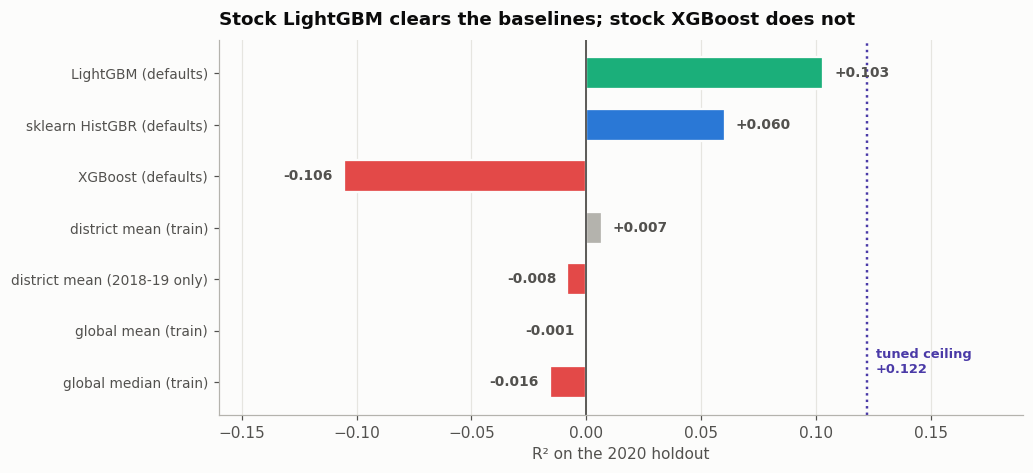

In [7]:
bd = pd.DataFrame(board).set_index("model")
order = ["global median (train)", "global mean (train)", "district mean (2018-19 only)",
         "district mean (train)", "XGBoost (defaults)", "sklearn HistGBR (defaults)",
         "LightGBM (defaults)"]
bd = bd.loc[[o for o in order if o in bd.index]]

fig, ax = plt.subplots(figsize=(9.5, 4.4))
cols = [RED if v < 0 else MUTED if v < 0.02 else BLUE for v in bd.r2]
cols[-1] = AQUA
ax.barh(range(len(bd)), bd.r2, height=0.62, color=cols,
        edgecolor=SURFACE, linewidth=1.5)
ax.axvline(0, color=INK2, lw=1.2)
ax.set_yticks(range(len(bd))); ax.set_yticklabels(bd.index, fontsize=9)
for i, v in enumerate(bd.r2):
    ax.annotate(f"{v:+.3f}", xy=(v, i), xytext=(7 if v > 0 else -7, 0),
                textcoords="offset points", va="center",
                ha="left" if v > 0 else "right", fontsize=9,
                color=INK2, fontweight="bold")
tuned_r2 = r2_score(y_hold, pred_tuned)
ax.axvline(tuned_r2, color=VIOLET, lw=1.6, ls=":")
ax.annotate(f"tuned ceiling\n{tuned_r2:+.3f}", xy=(tuned_r2, 0.4),
            xytext=(6, 0), textcoords="offset points", fontsize=8.5,
            color=VIOLET, fontweight="bold", va="center")
ax.set_xlim(-0.16, 0.19)
style(ax, "Stock LightGBM clears the baselines; stock XGBoost does not",
      "R² on the 2020 holdout", xgrid=True, ygrid=False)
fig.tight_layout(); plt.show()

Two findings, and the second is the more useful one.

**Stock LightGBM reaches +0.103**, roughly fifteen times the district-lookup
baseline. So the feature set carries genuine information beyond geography, and it
sits at **85% of the tuned model's +0.122** — tuning is worth having, but it is a
refinement, not the difference between working and not working.

**Stock XGBoost reaches −0.106**, worse than predicting a constant. Same data,
same features, same family of algorithm. The gap is default capacity plus the
categorical handling: XGBoost's defaults build deeper trees with no early
stopping, and feeding `district` as integer codes invites the model to split on a
meaningless ordering of 51 arbitrary labels. With only four training seasons,
that surplus capacity gets spent memorising season structure.

The lesson for the write-up is that **"we used a gradient-boosted tree" is not a
reproducible specification.** The library and its defaults are part of the result.

## 3 · Generalization — the answer depends on what you ask

The same stock LightGBM, scored three ways. These are not three estimates of one
quantity; they are three different questions, and they disagree by a factor of
three.

In [8]:
gen = []

# (a) Site-grouped CV inside the training years — the standard reported number.
cv = []
for f in sorted(full.loc[is_train, "cv_fold"].dropna().unique()):
    a = (is_train & (full.cv_fold != f)).fillna(False).astype(bool)
    b = (is_train & (full.cv_fold == f)).fillna(False).astype(bool)
    mm = lgb.LGBMRegressor(random_state=0, verbose=-1)
    mm.fit(X.loc[a], y[a])
    cv.append(r2_score(y[b], mm.predict(X.loc[b])))
gen.append(dict(protocol="site-grouped 5-fold CV\n(within training years)",
                r2=float(np.mean(cv)), sd=float(np.std(cv))))
print(f"site-grouped CV      R² = {np.mean(cv):+.4f} ± {np.std(cv):.4f}   "
      f"folds {np.round(cv, 3)}")

# (b) Leave-one-year-out, always training on the PAST only — the honest simulation
#     of how this model would have been used each season.
loyo = []
print()
for hy in (2017, 2018, 2019, 2020):
    a, b = full.year < hy, full.year == hy
    mm = lgb.LGBMRegressor(random_state=0, verbose=-1)
    mm.fit(X.loc[a], y[a])
    p = mm.predict(X.loc[b])
    r = r2_score(y[b], p)
    loyo.append(dict(year=hy, n_train=int(a.sum()), r2=r,
                     mae=mean_absolute_error(y[b], p)))
    print(f"  train < {hy} (n={a.sum():5,}) → predict {hy}: "
          f"R² = {r:+.4f}   MAE = {mean_absolute_error(y[b], p):,.0f}")
loyo = pd.DataFrame(loyo)
gen.append(dict(protocol="leave-one-year-out\n(mean across 4 seasons)",
                r2=float(loyo.r2.mean()), sd=float(loyo.r2.std())))
gen.append(dict(protocol="out-of-time holdout\n(2020, the reported number)",
                r2=r2_score(y_hold, pred_lgb), sd=0.0))

site-grouped CV      R² = +0.2965 ± 0.0335   folds [0.279 0.308 0.251 0.352 0.293]

  train < 2017 (n=3,876) → predict 2017: R² = +0.0061   MAE = 1,368


  train < 2018 (n=7,867) → predict 2018: R² = +0.0403   MAE = 1,242
  train < 2019 (n=12,112) → predict 2019: R² = +0.1741   MAE = 1,243


  train < 2020 (n=17,484) → predict 2020: R² = +0.1031   MAE = 1,151


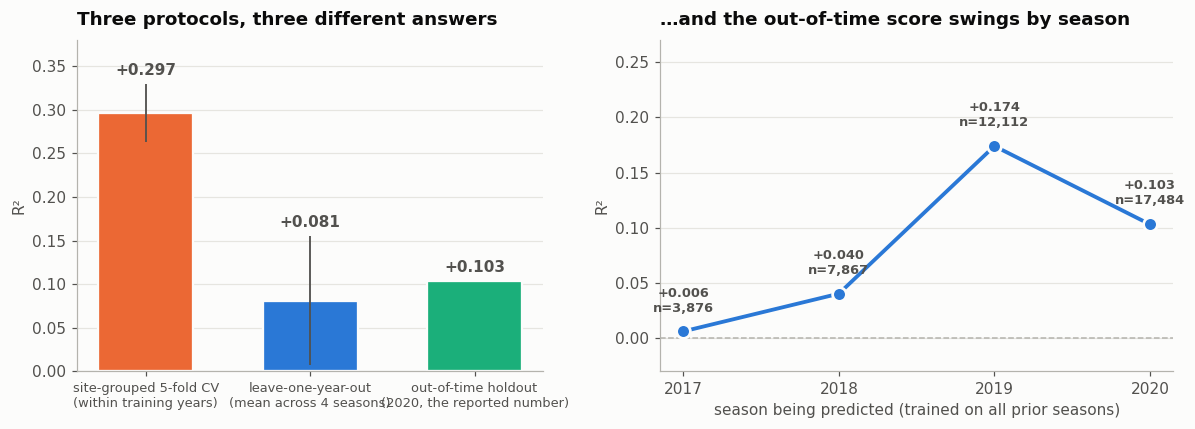

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4),
                         gridspec_kw={"width_ratios": [1, 1.1]})

ax = axes[0]
g = pd.DataFrame(gen)
cols = [ORANGE, BLUE, AQUA]
ax.bar(range(len(g)), g.r2, yerr=g.sd, width=0.58, color=cols,
       edgecolor=SURFACE, linewidth=1.5,
       error_kw=dict(ecolor=INK2, elinewidth=1.2, capsize=0))
for i, (v, s) in enumerate(zip(g.r2, g.sd)):
    ax.annotate(f"{v:+.3f}", xy=(i, v + s), xytext=(0, 6),
                textcoords="offset points", ha="center",
                fontweight="bold", fontsize=10, color=INK2)
ax.set_xticks(range(len(g)))
ax.set_xticklabels(g.protocol, fontsize=8.5)
ax.set_ylim(0, 0.38)
style(ax, "Three protocols, three different answers", None, "R²")

ax = axes[1]
ax.plot(loyo.year, loyo.r2, color=BLUE, lw=2.5, marker="o", markersize=9,
        markeredgecolor=SURFACE, markeredgewidth=1.8, zorder=3)
ax.axhline(0, color=MUTED, lw=1, ls="--")
for _, r in loyo.iterrows():
    ax.annotate(f"{r.r2:+.3f}\nn={r.n_train:,.0f}", xy=(r.year, r.r2),
                xytext=(0, 13), textcoords="offset points", ha="center",
                fontsize=8.5, color=INK2, fontweight="bold")
ax.set_xticks(loyo.year)
ax.set_ylim(-0.03, 0.27)
style(ax, "…and the out-of-time score swings by season",
      "season being predicted (trained on all prior seasons)", "R²")
fig.tight_layout(); plt.show()

**Site-grouped CV reports +0.297; the out-of-time holdout reports +0.103.** Both
are computed correctly. Grouped CV prevents a village from straddling the fold
boundary, but it still trains and validates *inside the same four seasons*, so the
model gets to see 2018's weather while predicting other 2018 plots. That is not
the situation it will ever be deployed in.

The right-hand panel is the more sobering one. Predicting each season from its
predecessors gives **+0.006, +0.040, +0.174, +0.103** — a range wide enough that
reporting any single one as "the model's performance" is a choice about which
story to tell. 2020 is neither the best nor the worst case, which is the main
reason it is a defensible number to quote.

Some of the upward drift is simply training-set size (3.9k → 17.5k rows), which
§4 separates out.

## 4 · Learning curve — is the ceiling data or signal?

If performance is still climbing with sample size, more seasons would help. If it
has flattened, the limit is the information in the features and no amount of extra
survey rounds will fix it. Each point averages five random subsamples of the
training rows, so the curve is not read off a single lucky draw.

In [10]:
idx = np.where(is_train)[0]
curve = []
for frac in (0.10, 0.25, 0.50, 0.75, 1.00):
    reps = []
    for seed in range(5):
        rng = np.random.default_rng(seed)
        sel = idx if frac == 1.0 else rng.choice(idx, int(len(idx) * frac), replace=False)
        mm = lgb.LGBMRegressor(random_state=0, verbose=-1)
        mm.fit(X.iloc[sel], y.iloc[sel])
        reps.append(r2_score(y_hold, mm.predict(X.loc[is_hold])))
        if frac == 1.0:
            break
    curve.append(dict(frac=frac, n=int(len(idx) * frac),
                      r2=float(np.mean(reps)), sd=float(np.std(reps))))
    print(f"  {frac:4.0%} of training rows (n={int(len(idx)*frac):6,}): "
          f"R² = {np.mean(reps):+.4f} ± {np.std(reps):.4f}")
curve = pd.DataFrame(curve)

   10% of training rows (n= 1,748): R² = +0.0043 ± 0.0217


   25% of training rows (n= 4,371): R² = +0.0327 ± 0.0124


   50% of training rows (n= 8,742): R² = +0.0718 ± 0.0182


   75% of training rows (n=13,113): R² = +0.0912 ± 0.0055


  100% of training rows (n=17,484): R² = +0.1031 ± 0.0000


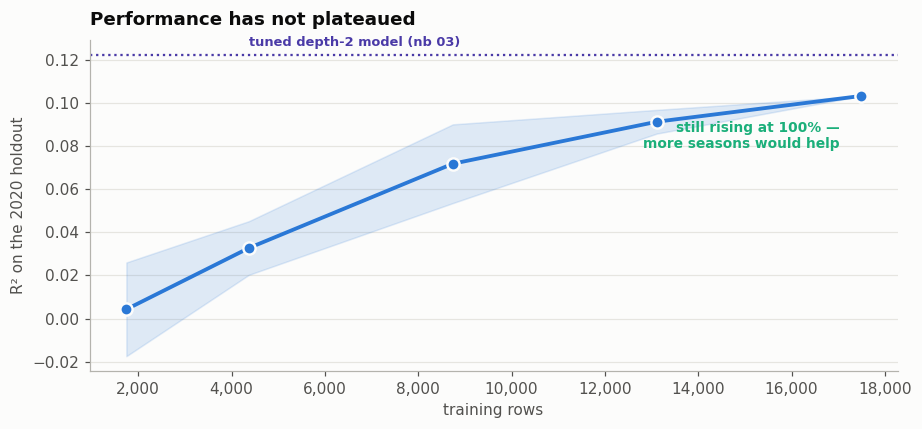

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.fill_between(curve.n, curve.r2 - curve.sd, curve.r2 + curve.sd,
                color=BLUE, alpha=0.14)
ax.plot(curve.n, curve.r2, color=BLUE, lw=2.5, marker="o", markersize=8,
        markeredgecolor=SURFACE, markeredgewidth=1.6, zorder=3)
ax.axhline(r2_score(y_hold, pred_tuned), color=VIOLET, lw=1.5, ls=":")
ax.annotate("tuned depth-2 model (nb 03)", xy=(curve.n.iloc[1], r2_score(y_hold, pred_tuned)),
            xytext=(0, 6), textcoords="offset points", fontsize=8.5,
            color=VIOLET, fontweight="bold")
ax.annotate("still rising at 100% —\nmore seasons would help",
            xy=(curve.n.iloc[-1], curve.r2.iloc[-1]), xytext=(-14, -34),
            textcoords="offset points", ha="right", fontsize=9,
            color=AQUA, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
style(ax, "Performance has not plateaued",
      "training rows", "R² on the 2020 holdout")
fig.tight_layout(); plt.show()

The curve is **monotone and still climbing** at the full training set: +0.004 →
+0.033 → +0.072 → +0.091 → +0.103. Nothing here looks like a plateau.

So the binding constraint is *data*, not (only) feature quality — and specifically
**seasons rather than rows**, since notebook 03 showed the model's difficulty is
generalizing across years. Another survey round is likely to buy more than another
round of feature engineering. That said, the ceiling being approached is modest:
extrapolating the trend does not suggest a plot-level R² anywhere near 0.3.

## 5 · Calibration — the model does not use its own range

R² and MAE summarise error but hide its *shape*. The single most important
property of this baseline is visible only when predictions are plotted against
outcomes.

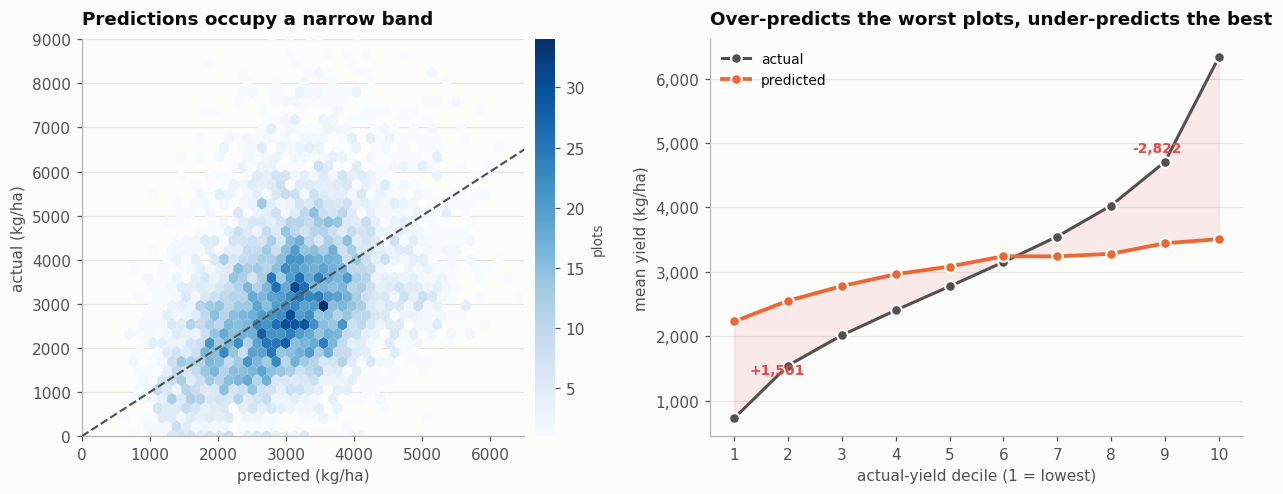

actual spread    sd = 1,591 kg/ha
predicted spread sd = 925 kg/ha (58% of actual)

prediction range: 628 to 6,474 kg/ha
actual range:     0 to 10,131 kg/ha


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

ax = axes[0]
hb = ax.hexbin(pred_lgb, y_hold, gridsize=42, cmap="Blues", mincnt=1, linewidths=0)
lim = [0, 9000]
ax.plot(lim, lim, color=INK2, lw=1.4, ls="--", zorder=3)
ax.annotate("perfect prediction", xy=(7000, 7000), xytext=(-6, 10),
            textcoords="offset points", ha="right", fontsize=8.5, color=INK2)
ax.set_xlim(0, 6500); ax.set_ylim(0, 9000)
cb = fig.colorbar(hb, ax=ax, pad=0.02); cb.set_label("plots", fontsize=9)
cb.outline.set_visible(False)
style(ax, "Predictions occupy a narrow band", "predicted (kg/ha)", "actual (kg/ha)")

ax = axes[1]
d = pd.DataFrame({"a": y_hold, "p": pred_lgb})
d["dec"] = pd.qcut(d.a, 10, labels=False, duplicates="drop")
gg = d.groupby("dec").agg(actual=("a", "mean"), pred=("p", "mean"), n=("a", "size"))
xs = np.arange(len(gg))
ax.plot(xs, gg.actual, color=INK2, lw=2, marker="o", markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=1.4, label="actual", zorder=3)
ax.plot(xs, gg.pred, color=ORANGE, lw=2.5, marker="o", markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=1.4, label="predicted", zorder=3)
ax.fill_between(xs, gg.pred, gg.actual, color=RED, alpha=0.10)
for i in (0, len(gg) - 1):
    ax.annotate(f"{gg.pred.iloc[i]-gg.actual.iloc[i]:+,.0f}",
                xy=(xs[i], (gg.pred.iloc[i] + gg.actual.iloc[i]) / 2),
                xytext=(10 if i == 0 else -24, 0), textcoords="offset points",
                ha="left" if i == 0 else "right", va="center",
                fontsize=9, color=RED, fontweight="bold")
ax.set_xticks(xs); ax.set_xticklabels([f"{i+1}" for i in xs])
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(loc="upper left", fontsize=9)
style(ax, "Over-predicts the worst plots, under-predicts the best",
      "actual-yield decile (1 = lowest)", "mean yield (kg/ha)")
fig.tight_layout(); plt.show()

print(f"actual spread    sd = {y_hold.std():,.0f} kg/ha")
print(f"predicted spread sd = {pred_lgb.std():,.0f} kg/ha "
      f"({pred_lgb.std()/y_hold.std():.0%} of actual)")
print(f"\nprediction range: {pred_lgb.min():,.0f} to {pred_lgb.max():,.0f} kg/ha")
print(f"actual range:     {y_hold.min():,.0f} to {y_hold.max():,.0f} kg/ha")

**Predicted yields have 58% of the spread of actual yields.** The hexbin is a
vertical smear: for almost any prediction the model makes, the true value ranges
across most of the distribution.

The decile plot quantifies the consequence. The worst-performing tenth of plots
average 729 kg/ha and are predicted at 2,229 — **over-predicted by ~1,500 kg/ha**.
The best tenth average 6,329 and are predicted at 3,508 — **under-predicted by
~2,800**. The model is pulled hard toward the middle.

This is not a bug to be tuned away; it is the correct behaviour of a squared-error
model on a weak signal. When features explain little, the risk-minimising
prediction *is* close to the conditional mean. But it has a sharp operational
consequence: **this model must never be used to tell an individual farmer what
they will harvest.** It will systematically flatter the worst-off and understate
the best.

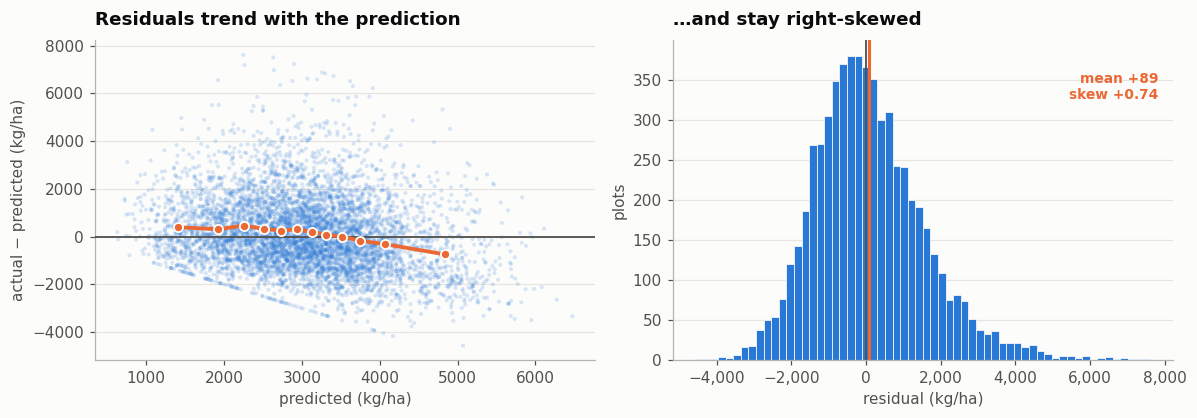

residual sd by prediction bin (heteroscedasticity check):
          p      r      sd
bin                       
0    1411.0  390.0  1213.0
1    1927.0  308.0  1314.0
2    2250.0  462.0  1424.0
3    2518.0  318.0  1488.0
4    2733.0  252.0  1543.0
5    2934.0  303.0  1495.0
6    3123.0  197.0  1485.0
7    3308.0   85.0  1509.0
8    3517.0   -5.0  1547.0
9    3743.0 -172.0  1496.0
10   4062.0 -315.0  1502.0
11   4843.0 -750.0  1551.0


In [13]:
resid = y_hold - pred_lgb
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))

ax = axes[0]
ax.axhline(0, color=INK2, lw=1.2, zorder=3)
ax.scatter(pred_lgb, resid, s=7, color=BLUE, alpha=0.18, edgecolor="none")
b = pd.DataFrame({"p": pred_lgb, "r": resid})
b["bin"] = pd.qcut(b.p, 12, labels=False, duplicates="drop")
bs = b.groupby("bin").agg(p=("p", "mean"), r=("r", "mean"), sd=("r", "std"))
ax.plot(bs.p, bs.r, color=ORANGE, lw=2.5, marker="o", markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1.2, zorder=4)
style(ax, "Residuals trend with the prediction",
      "predicted (kg/ha)", "actual − predicted (kg/ha)")

ax = axes[1]
ax.hist(resid, bins=60, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
ax.axvline(0, color=INK2, lw=1.2)
ax.axvline(resid.mean(), color=ORANGE, lw=2)
ax.annotate(f"mean {resid.mean():+,.0f}\nskew {stats.skew(resid):+.2f}",
            xy=(0.97, 0.9), xycoords="axes fraction", ha="right", va="top",
            fontsize=9, color=ORANGE, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
style(ax, "…and stay right-skewed", "residual (kg/ha)", "plots")
fig.tight_layout(); plt.show()

print("residual sd by prediction bin (heteroscedasticity check):")
print(bs.round(0).to_string())

The residual mean slopes from about **+390 kg/ha** at the lowest predictions to
**−750** at the highest — the mean-reversion of the previous figure, seen from the
model's own side. Residual *spread* is comparatively stable (~1,210–1,550 kg/ha),
so the problem is bias across the range rather than variance.

The right-skew is the crop-failure floor: yield cannot go below zero but can go to
10,000, so a squared-error model on the raw scale carries a permanent asymmetry.
Notebook 03 found a log transform makes out-of-time R² substantially *worse*
(−0.219), because back-transforming reintroduces bias where the zeros are, so the
skew is best treated as a known property rather than something to transform away.

## 6 · Practical accuracy — would a user accept these numbers?

R² is a modelling metric. An extension officer or a loan underwriter asks a
different question: how often is it about right?

2020 holdout, stock LightGBM
  within ±10% of actual :  16.9%
  within ±20% of actual :  32.9%
  within ±30% of actual :  48.2%
  within ±50% of actual :  70.6%

  median absolute error   : 932 kg/ha
  median actual yield     : 2,965 kg/ha
  median error as a share of median yield: 31%


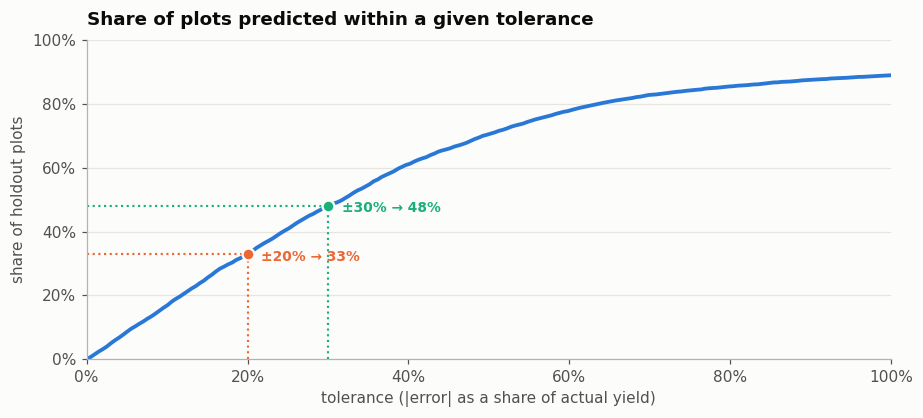

In [14]:
abs_err = np.abs(pred_lgb - y_hold)
ape = abs_err / np.maximum(y_hold, 1)   # guard the 326 zero-yield rows

print("2020 holdout, stock LightGBM")
for t in (0.10, 0.20, 0.30, 0.50):
    print(f"  within ±{t:.0%} of actual : {np.mean(ape <= t):6.1%}")
print(f"\n  median absolute error   : {np.median(abs_err):,.0f} kg/ha")
print(f"  median actual yield     : {np.median(y_hold):,.0f} kg/ha")
print(f"  median error as a share of median yield: {np.median(abs_err)/np.median(y_hold):.0%}")

fig, ax = plt.subplots(figsize=(8.5, 3.9))
grid = np.linspace(0, 1.0, 200)
hit = [(ape <= t).mean() for t in grid]
ax.plot(grid, hit, color=BLUE, lw=2.5)
for t, c in [(0.20, ORANGE), (0.30, AQUA)]:
    v = (ape <= t).mean()
    ax.plot([t, t], [0, v], color=c, lw=1.4, ls=":")
    ax.plot([0, t], [v, v], color=c, lw=1.4, ls=":")
    ax.scatter([t], [v], s=60, color=c, zorder=4, edgecolor=SURFACE, linewidth=1.5)
    ax.annotate(f"±{t:.0%} → {v:.0%}", xy=(t, v), xytext=(9, -4),
                textcoords="offset points", fontsize=9, color=c, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
style(ax, "Share of plots predicted within a given tolerance",
      "tolerance (|error| as a share of actual yield)", "share of holdout plots")
fig.tight_layout(); plt.show()

**One plot in three lands within ±20% of its true yield**, and the median error is
932 kg/ha against a median yield of 2,965 — about **31% off, typically**.

For per-farm advice or loan sizing on an individual plot, that is not good enough,
and no amount of the tuning in notebook 03 changes the order of magnitude
(the tuned model's MAE is 1,146 against this one's 1,151 — a 0.5% improvement).

## 7 · What the model *is* good for

A model can be a poor point-forecaster and still be a good **ranker**. Those are
different capabilities and they fail independently: mean-reversion destroys the
first while leaving the second largely intact, because compressing predictions
toward the middle preserves their order.

This matters because the actual use cases in the CRISP-DM report — targeting
extension visits, prioritising input packages, flagging plots at risk — need
*ordering*, not calibrated levels.

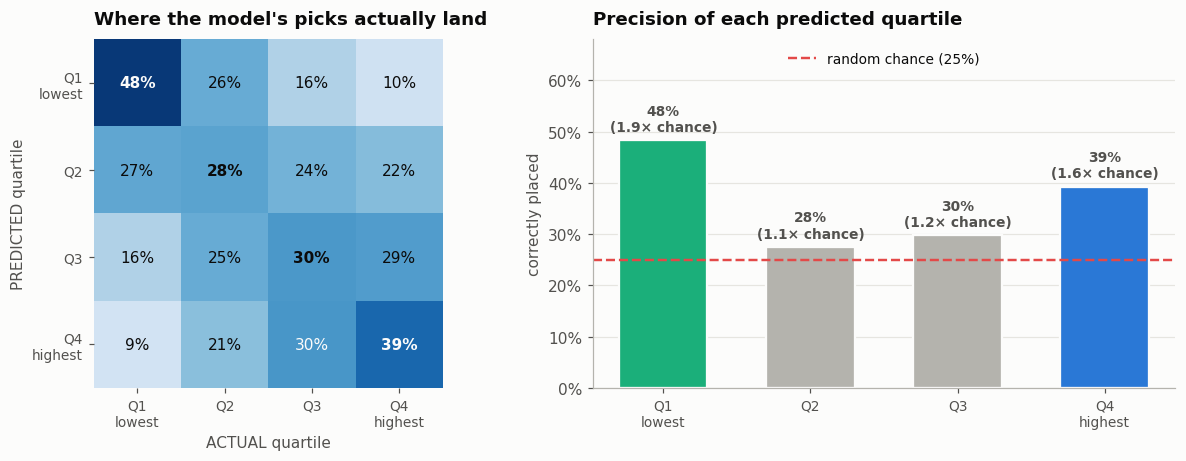

Rank-order correlation (Spearman ρ) : +0.401

Mean ACTUAL yield of the plots the model ranks:
  bottom quartile : 2,250 kg/ha
  top quartile    : 3,804 kg/ha
  separation      : 1,554 kg/ha (50% of mean yield)


In [15]:
q = pd.DataFrame({"a": y_hold, "p": pred_lgb})
q["actual_q"] = pd.qcut(q.a, 4, labels=False)
q["pred_q"]   = pd.qcut(q.p, 4, labels=False)
ct = pd.crosstab(q.pred_q, q.actual_q, normalize="index") * 100

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3),
                         gridspec_kw={"width_ratios": [1, 1.05]})

ax = axes[0]
im = ax.imshow(ct.to_numpy(), cmap="Blues", vmin=0, vmax=50)
for i in range(4):
    for j in range(4):
        v = ct.iloc[i, j]
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=10,
                color=SURFACE if v > 30 else INK,
                fontweight="bold" if i == j else "normal")
lab = ["Q1\nlowest", "Q2", "Q3", "Q4\nhighest"]
ax.set_xticks(range(4)); ax.set_xticklabels(lab, fontsize=9)
ax.set_yticks(range(4)); ax.set_yticklabels(lab, fontsize=9)
ax.set_xlabel("ACTUAL quartile"); ax.set_ylabel("PREDICTED quartile")
ax.set_title("Where the model's picks actually land", loc="left", pad=10)
ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)

ax = axes[1]
prec = [(q[q.pred_q == k].actual_q == k).mean() for k in range(4)]
bars = ax.bar(range(4), prec, width=0.6,
              color=[AQUA, MUTED, MUTED, BLUE], edgecolor=SURFACE, linewidth=1.5)
ax.axhline(0.25, color=RED, lw=1.6, ls="--", label="random chance (25%)")
for i, v in enumerate(prec):
    ax.annotate(f"{v:.0%}\n({v/0.25:.1f}× chance)", xy=(i, v), xytext=(0, 6),
                textcoords="offset points", ha="center", fontsize=9,
                color=INK2, fontweight="bold")
ax.set_xticks(range(4)); ax.set_xticklabels(lab, fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 0.68)
ax.legend(loc="upper center", fontsize=9)
style(ax, "Precision of each predicted quartile", None, "correctly placed")
fig.tight_layout(); plt.show()

lo, hi = q[q.pred_q == 0], q[q.pred_q == 3]
print(f"Rank-order correlation (Spearman ρ) : {stats.spearmanr(y_hold, pred_lgb).statistic:+.3f}")
print(f"\nMean ACTUAL yield of the plots the model ranks:")
print(f"  bottom quartile : {lo.a.mean():,.0f} kg/ha")
print(f"  top quartile    : {hi.a.mean():,.0f} kg/ha")
print(f"  separation      : {hi.a.mean()-lo.a.mean():,.0f} kg/ha "
      f"({(hi.a.mean()-lo.a.mean())/y_hold.mean():.0%} of mean yield)")

**This is the notebook's most useful result.**

Of the plots the model places in its bottom quartile, **48% are genuinely in the
bottom quartile** — 1.9× better than chance — and only 10% turn out to be
top-quartile. Its top-quartile picks are 39% correct, 1.6× chance. The plots it
ranks lowest average 2,250 kg/ha against 3,804 for those it ranks highest: a
**1,554 kg/ha separation, half the mean yield**, from a model that cannot predict
any individual plot within 30%.

So the honest summary of this baseline is: **a weak forecaster and a decent
prioritiser.** If the deliverable is "which farms should the extension team visit
first," this model is already useful. If it is "tell this farmer what they will
harvest," it is not, and more tuning will not make it so.

## 8 · Where the errors live

Aggregate metrics hide whether error is spread evenly or concentrated. Two cuts
matter operationally: by district (does the model fail somewhere specific?) and by
whether a district was seen in training at all.

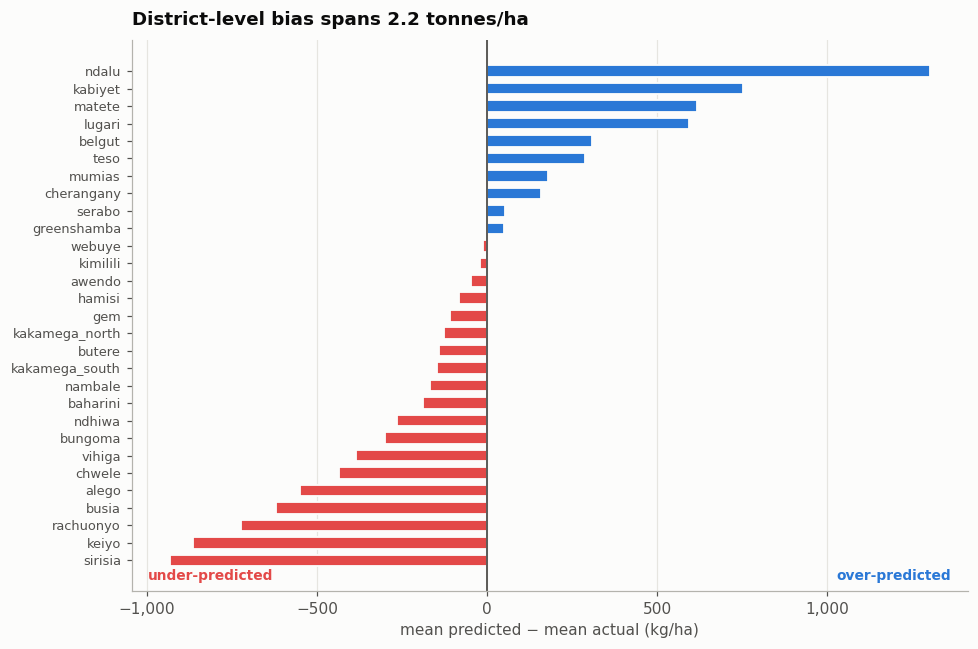

district bias range: -934 to +1,302 kg/ha across 29 districts with ≥100 holdout rows


In [16]:
err = pd.DataFrame({"district": full.loc[is_hold, "district"].astype(str).values,
                    "a": y_hold, "p": pred_lgb})
by_d = err.groupby("district").agg(n=("a", "size"), actual=("a", "mean"),
                                   pred=("p", "mean"))
by_d["bias"] = by_d.pred - by_d.actual
by_d = by_d[by_d.n >= 100].sort_values("bias")

fig, ax = plt.subplots(figsize=(9, 6))
cols = [RED if v < 0 else BLUE for v in by_d.bias]
ax.barh(range(len(by_d)), by_d.bias, height=0.66, color=cols,
        edgecolor=SURFACE, linewidth=1.2)
ax.axvline(0, color=INK2, lw=1.2)
ax.set_yticks(range(len(by_d))); ax.set_yticklabels(by_d.index, fontsize=8.5)
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
style(ax, "District-level bias spans 2.2 tonnes/ha",
      "mean predicted − mean actual (kg/ha)", xgrid=True, ygrid=False)
ax.annotate("under-predicted", xy=(0.02, 0.02), xycoords="axes fraction",
            fontsize=9, color=RED, fontweight="bold")
ax.annotate("over-predicted", xy=(0.98, 0.02), xycoords="axes fraction",
            ha="right", fontsize=9, color=BLUE, fontweight="bold")
fig.tight_layout(); plt.show()

print(f"district bias range: {by_d.bias.min():+,.0f} to {by_d.bias.max():+,.0f} kg/ha "
      f"across {len(by_d)} districts with ≥100 holdout rows")

In [17]:
seen   = set(full.loc[is_train, "district"].astype(str))
hd     = full.loc[is_hold, "district"].astype(str)
unseen = hd.isin(sorted(set(hd) - seen)).to_numpy()

print(f"{len(set(hd) - seen)} of {hd.nunique()} holdout districts never appear in "
      f"training, covering {unseen.sum():,} rows ({unseen.mean():.1%} of the holdout)\n")
for lab, m in [("seen in training", ~unseen), ("NEVER seen", unseen)]:
    print(f"  {lab:18s} n={m.sum():5,}  R²={r2_score(y_hold[m], pred_lgb[m]):+.4f}  "
          f"MAE={mean_absolute_error(y_hold[m], pred_lgb[m]):,.0f}  "
          f"actual sd={y_hold[m].std():,.0f}")

11 of 50 holdout districts never appear in training, covering 895 rows (14.5% of the holdout)

  seen in training   n=5,295  R²=+0.0651  MAE=1,136  actual sd=1,530
  NEVER seen         n=  895  R²=+0.2110  MAE=1,243  actual sd=1,869


Two things worth separating carefully here, because the first invites a wrong
conclusion.

**District bias is large and systematic.** `ndalu` is over-predicted by 1,302
kg/ha and `sirisia` under-predicted by 934 — a 2.2 t/ha span. Any district-level
aggregate from this model needs a bias correction before it is reported.

**The unseen-district result is a statistical artifact, not a finding.** Districts
absent from training score a *higher* R² (+0.211) than districts the model has
seen (+0.065), which reads like the model generalizes better to unfamiliar places
— an implausible claim. Their MAE tells the true story: **1,243 kg/ha versus
1,136, i.e. the errors are genuinely worse.** R² is normalised by each subgroup's
variance, and the unseen districts have a much wider yield spread (sd 1,869 vs
1,530), so the same absolute error divided by a bigger denominator looks like
better performance.

This is a good general warning for the write-up: **never compare R² across
subgroups with different variances.** Compare MAE or RMSE, or normalise
deliberately.

## 9 · Verdict

In [18]:
summary = pd.DataFrame([
    dict(metric="R² (out-of-time 2020)",        baseline=r2_score(y_hold, pred_lgb),
         tuned_nb03=r2_score(y_hold, pred_tuned), district_lookup=0.0068),
    dict(metric="MAE (kg/ha)",                  baseline=mean_absolute_error(y_hold, pred_lgb),
         tuned_nb03=mean_absolute_error(y_hold, pred_tuned), district_lookup=1237.9),
    dict(metric="RMSE (kg/ha)",                 baseline=float(np.sqrt(mean_squared_error(y_hold, pred_lgb))),
         tuned_nb03=float(np.sqrt(mean_squared_error(y_hold, pred_tuned))), district_lookup=1585.3),
    dict(metric="Spearman ρ",                   baseline=stats.spearmanr(y_hold, pred_lgb).statistic,
         tuned_nb03=stats.spearmanr(y_hold, pred_tuned).statistic, district_lookup=0.233),
]).set_index("metric")
print(summary.round(3).to_string())
print(f"\nbaseline model: LGBMRegressor(random_state=0) — library defaults, "
      f"{len(FEATS)} features, no tuning")

                       baseline  tuned_nb03  district_lookup
metric                                                      
R² (out-of-time 2020)     0.103       0.122            0.007
MAE (kg/ha)            1151.444    1145.760         1237.900
RMSE (kg/ha)           1506.502    1490.597         1585.300
Spearman ρ                0.401       0.401            0.233

baseline model: LGBMRegressor(random_state=0) — library defaults, 66 features, no tuning


### What this baseline establishes

1. **Stock LightGBM, no tuning: R² = +0.103, MAE = 1,151 kg/ha on an unseen
   season.** That is the number every later model must beat, and it is the number
   to quote — not the CV figure.
2. **It beats a district-mean lookup fifteen-fold** (+0.103 vs +0.007), so the
   agronomic and environmental features are contributing real information.
3. **Tuning buys +0.019 R² and 0.5% on MAE.** Notebook 03's careful
   depth-2 specification is worth having, but the baseline already captures ~85%
   of the achievable performance. Effort is better spent on data than on search.
4. **Library defaults are part of the specification.** LightGBM +0.103, sklearn
   HistGBR +0.060, XGBoost −0.106 — same data, same features. Report the library
   and version.
5. **Site-grouped CV overstates by ~2.9×** (+0.297 vs +0.103). Grouping by site
   does not fix the fact that CV trains and tests within the same seasons.
6. **Season-to-season performance is unstable** (+0.006 to +0.174 across
   leave-one-year-out). Any single-season figure, including this one, should be
   quoted with that range attached.
7. **The learning curve has not plateaued.** More seasons would help more than
   more feature engineering.
8. **Predictions have 58% of the spread of outcomes**, over-predicting the worst
   decile by ~1,500 kg/ha and under-predicting the best by ~2,800. Never surface
   a per-farm yield number from this model.
9. **But it ranks well enough to act on**: 48% precision on its bottom-quartile
   picks (1.9× chance), separating high from low by 1,554 kg/ha.
10. **District bias spans 2.2 t/ha** and needs correcting before any district
    aggregate is published.

### Recommended framing for the report

> The baseline gradient-boosted model explains ~10% of out-of-season variance in
> plot-level maize yield (R² = 0.10, MAE = 1,151 kg/ha), which is fifteen times a
> district-average benchmark but far from a usable per-farm forecast. Its value is
> in **prioritisation**: it identifies the lowest-yielding quartile of plots with
> 48% precision against a 25% chance rate. Yield-level outputs should be reported
> at district scale with a bias correction, never at plot scale to an individual
> farmer.

### Next steps

| Priority | Action |
|---|---|
| High | Adopt this as the registered baseline; require any candidate model to beat +0.103 **on the out-of-time holdout**, not on CV. |
| High | Reframe the deliverable around ranking. Evaluate candidates on quartile precision and Spearman ρ alongside R². |
| Medium | Fit district-level bias corrections before publishing any aggregate. |
| Medium | Report the leave-one-year-out range (+0.006 to +0.174) wherever a headline R² appears. |
| Low | Revisit tuning only after more seasons are available — the learning curve says data, not search, is the constraint. |